# Boston EDA

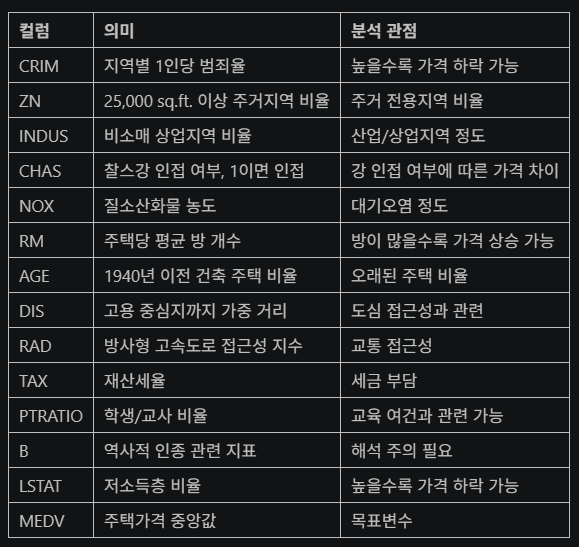

In [ ]:
# ==============================
# 1) 라이브러리 불러오기
# ==============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, ttest_ind

In [ ]:
# ==============================
# 2) 데이터 불러오기
# ==============================

df = pd.read_csv("boston.csv")

print(df.head())

# 분석
# MEDV는 주택가격을 의미하는 변수임

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  


In [ ]:
# ==============================
# 3) 데이터 구조 확인
# ==============================

df.info()

print("행/열 개수:", df.shape)
print("컬럼명:", df.columns.tolist())

# 분석
# Boston 데이터는 506행, 14개 컬럼으로 구성되어 있음
# 대부분 숫자형 데이터로 구성

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB
행/열 개수: (506, 14)
컬럼명: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']


In [ ]:
# ==============================
# 4) 결측치 확인
# ==============================

print(df.isnull().sum())

# 분석
# 결측치가 모두 0이면 따로 제거하거나 채우는 과정이 필요 없음

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [ ]:
# ==============================
# 5) 기초 통계량 확인
# ==============================

print(df.describe())

             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              AGE         DIS         RAD         TAX     PTRATIO           B  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.574901    3.795043    9.549407  408.237154   18.455534  356.674032   
std     28.148861    2.1057

count    506.000000
mean      22.532806
std        9.197104
min        5.000000
25%       17.025000
50%       21.200000
75%       25.000000
max       50.000000
Name: MEDV, dtype: float64

MEDV=50인 행 개수: 16


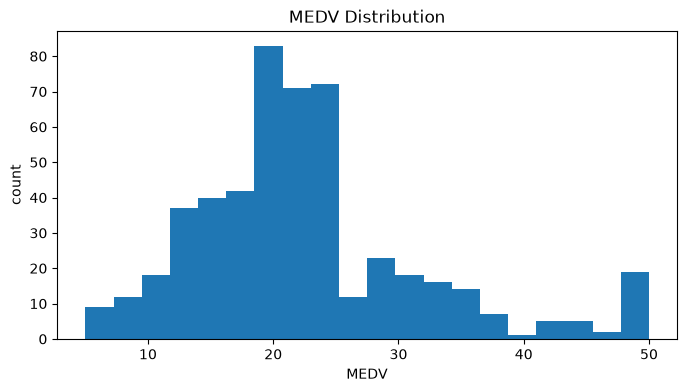

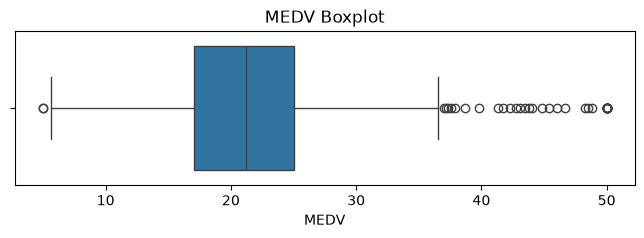

In [ ]:
# ==============================
# 6) MEDV 주택가격 분포
# ==============================

print(df["MEDV"].describe())
print("\nMEDV=50인 행 개수:", (df["MEDV"] == 50).sum())

plt.figure(figsize=(8, 4))
plt.hist(df["MEDV"], bins=20)
plt.ylabel("count")
plt.title("MEDV Distribution")
plt.xlabel("MEDV")
plt.show()

plt.figure(figsize=(8, 2))
sns.boxplot(x=df["MEDV"])
plt.title("MEDV Boxplot")
plt.show()

# 분석
# 대부분의 주택가격은 15~25 구간에 몰려 있음
# 평균은 약 22.53, 중앙값은 약 21.20으로 큰 차이는 아님
# 최댓값 50.0이 16개 존재

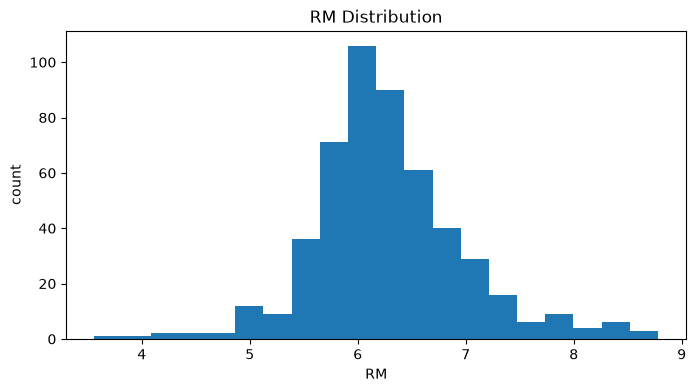

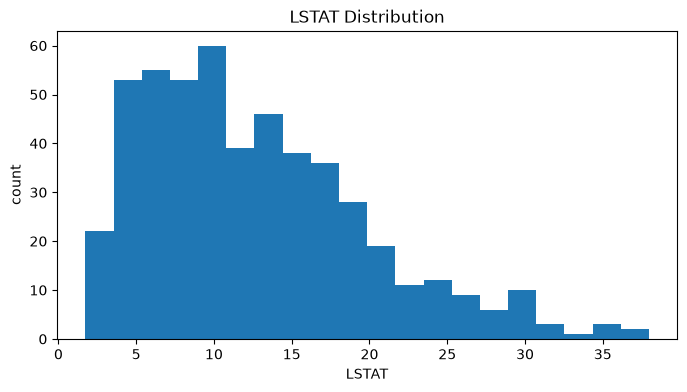

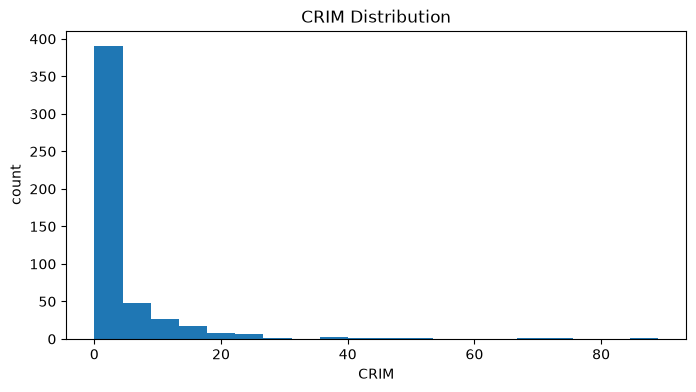

In [ ]:
# ==============================
# 7) 주요 변수 분포 확인
# ==============================

cols = ["RM", "LSTAT", "CRIM"]

for col in cols:
    plt.figure(figsize=(8, 4))
    plt.hist(df[col], bins=20)
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.show()

# 분석
# RM : 평균 방 개수
# LSTAT :  저소득층 비율
# CRIM : 범죄율
# 세 변수는 집값과 관련이 있을 가능성이 있어 분포를 확인함

In [ ]:
# ==============================
# 8) MEDV와 다른 변수들의 상관관계 확인
# ==============================

corr = df.corr(numeric_only=True)

medv_corr = corr["MEDV"].sort_values(ascending=False)
print(medv_corr)

# 분석
# RM은 MEDV와 양의 상관관계를 보이는 대표적인 변수
# LSTAT는 MEDV와 음의 상관관계를 보이는 대표적인 변수

MEDV       1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64


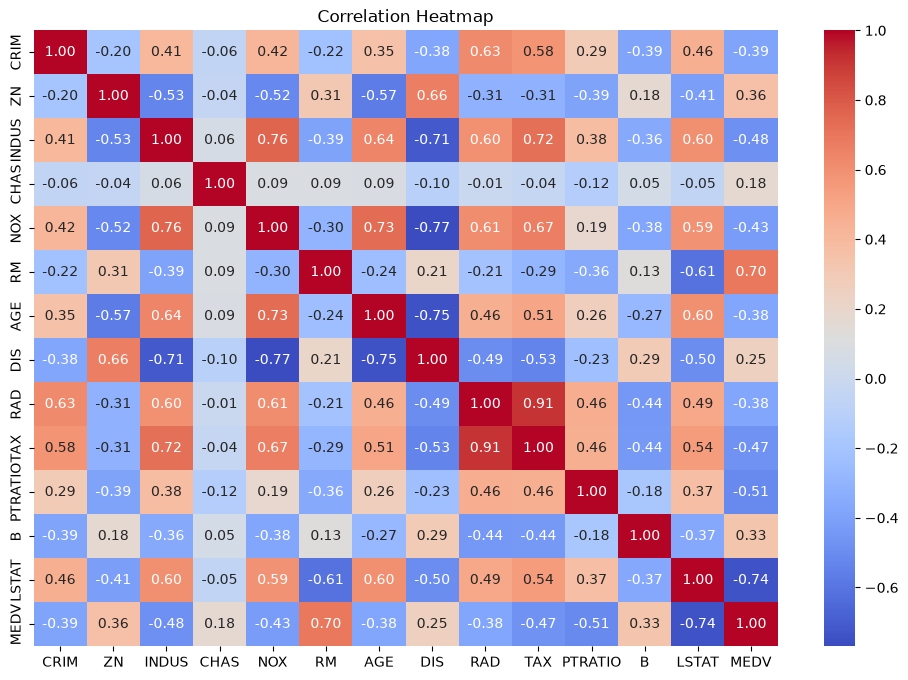

In [ ]:
# ==============================
# 9) 상관관계 히트맵
# ==============================

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# 분석
# heatmap은 변수 간 상관관계를 색으로 표현
# 색이 진할수록 변수 간 관계가 강하다고 볼 수 있음

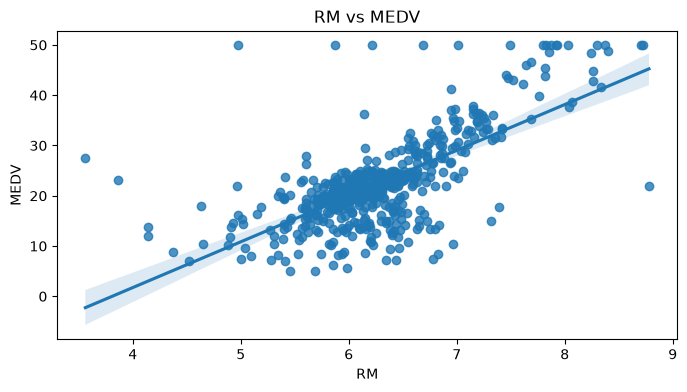

In [ ]:
# ==============================
# 10) RM과 MEDV 관계 확인
# ==============================

plt.figure(figsize=(8, 4))
sns.regplot(x="RM", y="MEDV", data=df)
plt.title("RM vs MEDV")
plt.xlabel("RM")
plt.ylabel("MEDV")
plt.show()

# 분석
# 그래프에서 추세선이 오른쪽 위로 향하면 양의 관계를 의미함
# 평균 방 개수가 많을수록 집값이 높아지는 경향이 있음

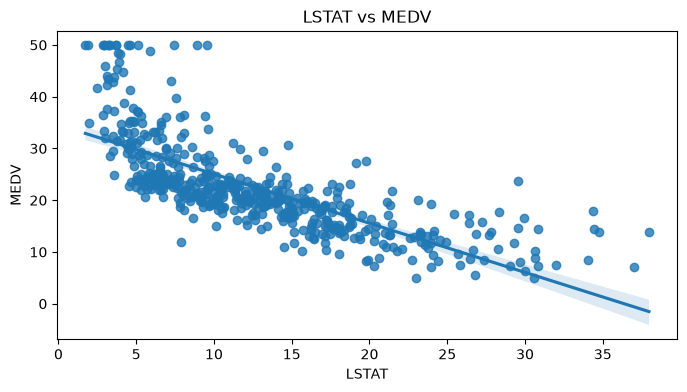

In [ ]:
# ==============================
# 11) LSTAT와 MEDV 관계 확인
# ==============================

plt.figure(figsize=(8, 4))
sns.regplot(x="LSTAT", y="MEDV", data=df)
plt.title("LSTAT vs MEDV")
plt.xlabel("LSTAT")
plt.ylabel("MEDV")
plt.show()

# 분석
# 그래프에서 추세선이 오른쪽 아래로 향하면 음의 관계를 의미함
# 저소득층 비율이 높을수록 집값이 낮아지는 경향이 있음

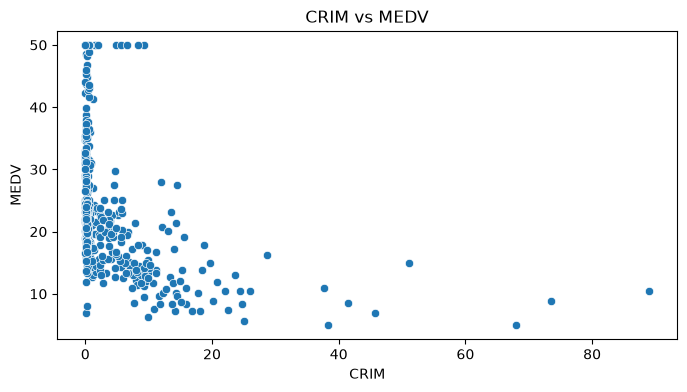

In [ ]:
# ==============================
# 12) CRIM과 MEDV 관계 확인
# ==============================

plt.figure(figsize=(8, 4))
sns.scatterplot(x="CRIM", y="MEDV", data=df)
plt.title("CRIM vs MEDV")
plt.xlabel("CRIM")
plt.ylabel("MEDV")
plt.show()

# 분석
# 범죄율이 낮은 지역에 다양한 집값이 분포하고 있음
# 범죄율이 높은 지역에서는 상대적으로 집값이 낮은 경향을 보임
# 다만 CRIM은 값이 한쪽으로 치우쳐 있어서 조금 애매함

In [ ]:
# ==============================
# 13) RM 평균 기준으로 그룹 나누기
# ==============================

rm_mean = df["RM"].mean()

df["RM_group"] = df["RM"].apply(lambda x: "방 많음" if x >= rm_mean else "방 적음")

print(df[["RM", "RM_group", "MEDV"]].head())

# 분석
# RM 평균값을 기준으로 방 개수가 많은 그룹과 적은 그룹을 나눔

      RM RM_group  MEDV
0  6.575     방 많음  24.0
1  6.421     방 많음  21.6
2  7.185     방 많음  34.7
3  6.998     방 많음  33.4
4  7.147     방 많음  36.2


RM_group
방 많음    27.417105
방 적음    18.526978
Name: MEDV, dtype: float64


C:\Users\user\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47566 (\N{HANGUL SYLLABLE MANH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


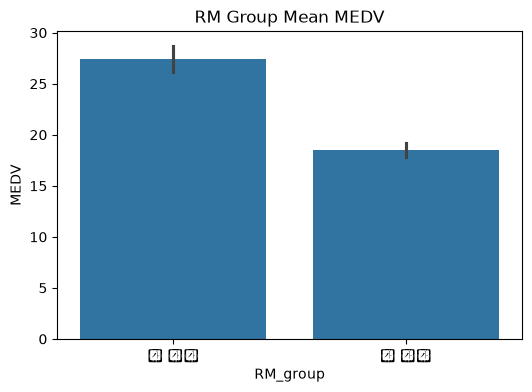

In [ ]:
# ==============================
# 14) RM 그룹별 MEDV 평균 비교
# ==============================

rm_group_result = df.groupby("RM_group")["MEDV"].mean()
print(rm_group_result)

plt.figure(figsize=(6, 4))
sns.barplot(x="RM_group", y="MEDV", data=df)
plt.title("RM Group Mean MEDV")
plt.xlabel("RM_group")
plt.ylabel("MEDV")
plt.show()

# 분석
# 방 많음 그룹의 평균 집값이 더 높게 나타날 가능성이 큼
# 이를 통해 방 개수는 집값과 관련이 있는 변수

      count       mean
CHAS                  
0.0     471  22.093843
1.0      35  28.440000


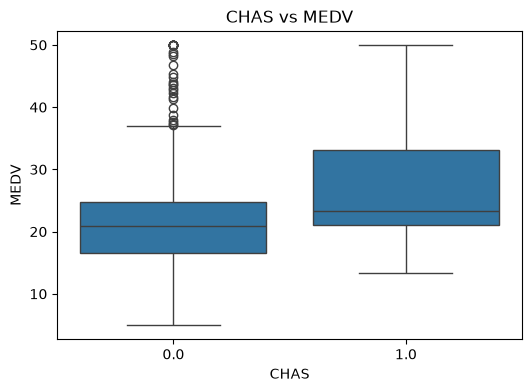

In [ ]:
# ==============================
# 15) CHAS에 따른 MEDV 평균 비교
# ==============================

chas_result = df.groupby("CHAS")["MEDV"].agg(["count", "mean"])
print(chas_result)

plt.figure(figsize=(6, 4))
sns.boxplot(x="CHAS", y="MEDV", data=df)
plt.title("CHAS vs MEDV")
plt.xlabel("CHAS")
plt.ylabel("MEDV")
plt.show()


# 0은 찰스강과 인접하지 않은 지역, 1은 찰스강과 인접한 지역

In [ ]:
# ==============================
# 16) 가설검정 1: RM과 MEDV는 상관관계가 있는가?
# ==============================

# H0: RM과 MEDV는 상관관계가 없다.
# H1: RM과 MEDV는 상관관계가 있다.

st, pv = pearsonr(df["RM"], df["MEDV"])

print("상관계수:", st)
print("p-value:", pv)

if pv < 0.05:
    print("결론: RM과 MEDV는 통계적으로 유의미한 상관관계가 있다.")
else:
    print("결론: RM과 MEDV는 통계적으로 유의미한 상관관계가 있다고 보기 어렵다.")

# 분석
# p < 0.05 보다 작음
# 방 갯수와 집값은 통계적으로 유의미한 관계가 있음

상관계수: 0.6953599470715395
p-value: 2.4872288710076306e-74
결론: RM과 MEDV는 통계적으로 유의미한 상관관계가 있다.


In [ ]:
# ==============================
# 17) 가설검정 2: LSTAT와 MEDV는 상관관계가 있는가?
# ==============================

# H0: LSTAT와 MEDV는 상관관계가 없다.
# H1: LSTAT와 MEDV는 상관관계가 있다.

st, pv = pearsonr(df["LSTAT"], df["MEDV"])

print("상관계수:", st)
print("p-value:", pv)

if pv < 0.05:
    print("결론: LSTAT와 MEDV는 통계적으로 유의미한 상관관계가 있다.")
else:
    print("결론: LSTAT와 MEDV는 통계적으로 유의미한 상관관계가 있다고 보기 어렵다.")

# 분석
# p < 0.05 보다 작음
# 저소득층 비율과 집값은 통계적으로 유의미한 관계가 있음

상관계수: -0.7376627261740148
p-value: 5.081103394387441e-88
결론: LSTAT와 MEDV는 통계적으로 유의미한 상관관계가 있다.


In [ ]:
# ==============================
# 18) 가설검정 3: CHAS에 따라 MEDV 평균 차이가 있는가?
# ==============================

# H0: CHAS=0과 CHAS=1의 MEDV 평균은 차이가 없다.
# H1: CHAS=0과 CHAS=1의 MEDV 평균은 차이가 있다.

chas_0 = df[df["CHAS"] == 0]["MEDV"]
chas_1 = df[df["CHAS"] == 1]["MEDV"]

st, pv = ttest_ind(chas_1, chas_0, equal_var=False)

print("CHAS=0 평균:", chas_0.mean())
print("CHAS=1 평균:", chas_1.mean())
print("t값:", st)
print("p-value:", pv)

if pv < 0.05:
    print("결론: CHAS에 따라 MEDV 평균 차이가 있다.")
else:
    print("결론: CHAS에 따라 MEDV 평균 차이가 있다고 보기 어렵다.")

# 분석
# p < 0.05 보다 작음
# CHAS와 집값은 통계적으로 유의미한 관계가 있음

CHAS=0 평균: 22.093842887473464
CHAS=1 평균: 28.439999999999998
t값: 3.113291312794837
p-value: 0.003567170098137519
결론: CHAS에 따라 MEDV 평균 차이가 있다.


In [ ]:
# ==============================
# 19) 최종 분석 결과 정리
# ==============================

# 최종 분석 결과
# 1. RM은 MEDV와 양의 관계를 보임
# 2. LSTAT는 MEDV와 음의 관계를 보임
# 3. CHAS에 따라 MEDV 평균 차이가 있을 가능성이 있음
# 4. Boston 데이터에서 집값과 관련이 큰 변수는 RM, LSTAT, CHAS로 볼 수 있음

# 분석
# Boston 주택 데이터를 사용하여 기본 EDA와 간단한 가설검정을 진행함
# 데이터 구조, 결측치, 중복값, 기초 통계량을 먼저 확인함
# 히스토그램과 boxplot으로 MEDV의 분포와 이상치 가능성을 확인함
# 상관관계 분석 결과 RM은 집값과 양의 관계를 보임
# LSTAT는 집값과 음의 관계를 보임
# CHAS는 집값 평균 차이를 확인할 수 있는 범주형 변수로 사용함
# 전체적으로 RM, LSTAT, CHAS가 MEDV와 관련 있는 주요 변수라고 판단함


# 결론 : 방 개수가 많거나 찰스강과 인접하면 집값은 높아질 확률이 높고, 저소득층 비율이 높을수록 집값은 낮아질 확률이 높다.